100%|██████████| 12000/12000 [00:00<00:00, 200850.18it/s]


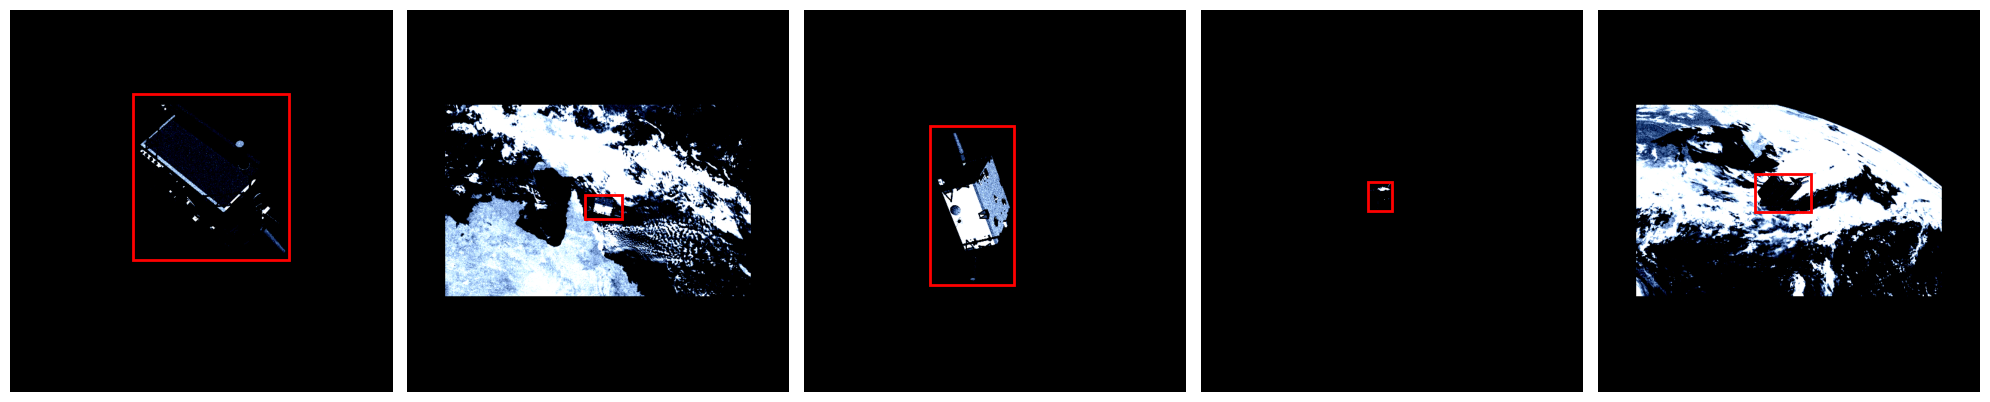

100%|██████████| 1920/1920 [01:40<00:00, 19.17it/s]


In [1]:
import os
import json
from torch.utils.data import Dataset
import tqdm
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
import matplotlib.patches as patches
from torchvision import transforms
from scipy.io import loadmat
import cv2

def convert_to_yolo_format(dataset, output_dir, split_name):
    """Convert your dataset to YOLO format - saves TRANSFORMED images with matching boxes"""
    import tqdm
    from PIL import Image
    
    images_dir = os.path.join(output_dir, 'images', split_name)
    labels_dir = os.path.join(output_dir, 'labels', split_name)
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)

    for idx in tqdm.tqdm(range(len(dataset))):
        image, box = dataset[idx]
        
        # Get base filename
        if hasattr(dataset, 'dataset') and hasattr(dataset, 'indices'):
            # For torch.utils.data.Subset
            original_filename = dataset.dataset.imagesList[dataset.indices[idx]]
        else:
            # For regular dataset
            original_filename = dataset.imagesList[idx]
        base_name = os.path.splitext(os.path.basename(original_filename))[0]
        
        # IMPORTANT: Save the TRANSFORMED image, not the original
        # The image tensor is normalized, so we need to denormalize it
        if isinstance(image, torch.Tensor):
            # Denormalize the image
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            image = image * std + mean
            image = torch.clamp(image, 0, 1)
            
            # Convert to PIL Image and save
            image_np = (image.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            image_pil = Image.fromarray(image_np)
            image_pil.save(os.path.join(images_dir, f"{base_name}.jpg"))
        
        # Convert bounding box to YOLO format (normalized coordinates)
        img_width, img_height = 640, 640  # Your image size after transformation
        xmin, ymin, w, h = box.tolist() if isinstance(box, torch.Tensor) else box
        
        x_center = (xmin + w/2) / img_width
        y_center = (ymin + h/2) / img_height
        norm_width = w / img_width
        norm_height = h / img_height
        
        class_id = 0
        
        # Save annotation
        with open(os.path.join(labels_dir, f"{base_name}.txt"), 'w') as f:
            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {norm_width:.6f} {norm_height:.6f}\n")


class SPEEDDataset(Dataset):
    def __init__(self, images_dir, json_dir, tango_points_dir, camera_matrix_dir, transform=None, is_train=True):
        self.image_width = 1920
        self.image_height = 1200
        self.aspect_ratio = self.image_width * 1.0 / self.image_height
        self.pixel_std = 200
        self.num_joints = 11
        self.image_size = [640, 640]
        self.scale_factor = 0.25
        self.rotation_factor = 30
        self.sigma = 2
        self.is_train = is_train
        self.transform = transform

        self.imagesList = []
        self.frameInfoList = []
        self.images_dir = images_dir
        self.json_dir = json_dir

        self.keypts3d = self.load_tango_3d_keypoints(tango_points_dir) # https://www.desmos.com/3d/jud6lng9gn
        self.cameraMatrix, self.distCoeffs = self.load_camera_intrinsics(camera_matrix_dir)

        with open(self.json_dir, 'r') as f:
            annotations = json.load(f)
            lookup = { item['filename']: item for item in annotations }
            cnt = 0
            for filename in tqdm.tqdm(sorted(os.listdir(self.images_dir))):
                if filename not in lookup:
                    continue
                frame_idx = int(''.join(filter(str.isdigit, filename.split('.')[0])))
                self.imagesList.append(os.path.join(self.images_dir, filename))

                q_vbs2tango = np.array(lookup[filename]["q_vbs2tango"], dtype=np.float32)
                r_Vo2To_vbs = np.array(lookup[filename]['r_Vo2To_vbs_true'], dtype=np.float32)

                frame_info = {
                    'filename': filename,
                    'q_vbs2tango': q_vbs2tango,
                    'r_Vo2To_vbs': r_Vo2To_vbs
                }
                self.frameInfoList.append(frame_info)

                cnt = cnt + 1
                # if cnt>20:
                #     break

    def __len__(self):
        return len(self.imagesList)
    
    def quat2dcm(self, q):
        """ Computing direction cosine matrix from quaternion, adapted from PyNav.
        Arguments:
            q: (4,) numpy.ndarray - unit quaternion (scalar-first)
        Returns:
            dcm: (3,3) numpy.ndarray - corresponding DCM
        """

        # normalizing quaternion
        q = q / np.linalg.norm(q)

        q0, q1, q2, q3 = q[0], q[1], q[2], q[3]
        dcm = np.zeros((3, 3))
        dcm[0, 0] = 2 * q0 ** 2 - 1 + 2 * q1 ** 2
        dcm[1, 1] = 2 * q0 ** 2 - 1 + 2 * q2 ** 2
        dcm[2, 2] = 2 * q0 ** 2 - 1 + 2 * q3 ** 2
        dcm[0, 1] = 2 * q1 * q2 + 2 * q0 * q3
        dcm[0, 2] = 2 * q1 * q3 - 2 * q0 * q2
        dcm[1, 0] = 2 * q1 * q2 - 2 * q0 * q3
        dcm[1, 2] = 2 * q2 * q3 + 2 * q0 * q1
        dcm[2, 0] = 2 * q1 * q3 + 2 * q0 * q2
        dcm[2, 1] = 2 * q2 * q3 - 2 * q0 * q1

        return dcm

    def load_tango_3d_keypoints(self, mat_dir):
        vertices = loadmat(mat_dir)['tango3Dpoints']
        corners3D = np.transpose(np.array(vertices, dtype=np.float32))
        return corners3D

    def load_camera_intrinsics(self, camera_json):
        with open(camera_json) as f:
            cam = json.load(f)
        cameraMatrix = np.array(cam['cameraMatrix'], dtype=np.float32)
        distCoeffs = np.array(cam['distCoeffs'], dtype=np.float32)
        return cameraMatrix, distCoeffs

    def project_keypoints(self, q_vbs2tango, r_Vo2To_vbs, cameraMatrix, distCoeffs, keypoints):
        if keypoints.shape[0] != 3:
            keypoints = np.transpose(keypoints)
        keypoints = np.vstack((keypoints, np.ones((1, keypoints.shape[1]))))
        pose_mat = np.hstack((np.transpose(self.quat2dcm(q_vbs2tango)),
                              np.expand_dims(r_Vo2To_vbs, 1)))
        xyz = np.dot(pose_mat, keypoints)
        x0, y0 = xyz[0, :] / xyz[2, :], xyz[1, :] / xyz[2, :]
        r2 = x0 * x0 + y0 * y0
        cdist = 1 + distCoeffs[0] * r2 + distCoeffs[1] * r2 * r2 + distCoeffs[4] * r2 * r2 * r2
        x = x0 * cdist + distCoeffs[2] * 2 * x0 * y0 + distCoeffs[3] * (r2 + 2 * x0 * x0)
        y = y0 * cdist + distCoeffs[2] * (r2 + 2 * y0 * y0) + distCoeffs[3] * 2 * x0 * y0
        points2D = np.vstack((cameraMatrix[0, 0] * x + cameraMatrix[0, 2],
                              cameraMatrix[1, 1] * y + cameraMatrix[1, 2]))
        return points2D

    def _box2cs(self, box):
        x, y, w, h = box[:4]
        return self._xywh2cs(x, y, w, h)

    def _xywh2cs(self, x, y, w, h):
        center = np.zeros((2), dtype=np.float32)
        center[0] = x + w * 0.5
        center[1] = y + h * 0.5

        if w > self.aspect_ratio * h:
            h = w * 1.0 / self.aspect_ratio
        elif w < self.aspect_ratio * h:
            w = h * self.aspect_ratio
        scale = np.array(
            [w * 1.0 / self.pixel_std, h * 1.0 / self.pixel_std],
            dtype=np.float32)
        if center[0] != -1:
            scale = scale * 1.25

        return center, scale

    def get_affine_transform(self, center, scale, rot, output_size, shift=np.array([0, 0], dtype=np.float32), inv=0):
        if not isinstance(scale, np.ndarray) and not isinstance(scale, list):
            scale = np.array([scale, scale])
        scale_tmp = scale * 200.0
        src_w = scale_tmp[0]
        dst_w = output_size[0]
        dst_h = output_size[1]
        rot_rad = np.pi * rot / 180
        src_dir = self.get_dir([0, src_w * -0.5], rot_rad)
        dst_dir = np.array([0, dst_w * -0.5], np.float32)
        src = np.zeros((3, 2), dtype=np.float32)
        dst = np.zeros((3, 2), dtype=np.float32)
        src[0, :] = center + scale_tmp * shift
        src[1, :] = center + src_dir + scale_tmp * shift
        dst[0, :] = [dst_w * 0.5, dst_h * 0.5]
        dst[1, :] = np.array([dst_w * 0.5, dst_h * 0.5]) + dst_dir
        src[2:, :] = self.get_3rd_point(src[0, :], src[1, :])
        dst[2:, :] = self.get_3rd_point(dst[0, :], dst[1, :])
        if inv:
            trans = cv2.getAffineTransform(np.float32(dst), np.float32(src))
        else:
            trans = cv2.getAffineTransform(np.float32(src), np.float32(dst))
        return trans

    def affine_transform(self, pt, t):
        new_pt = np.array([pt[0], pt[1], 1.]).T
        new_pt = np.dot(t, new_pt)
        return new_pt[:2]
    
    def get_3rd_point(self, a, b):
        direct = a - b
        return b + np.array([-direct[1], direct[0]], dtype=np.float32)
    
    def get_dir(self, src_point, rot_rad):
        sn, cs = np.sin(rot_rad), np.cos(rot_rad)
        src_result = [0, 0]
        src_result[0] = src_point[0] * cs - src_point[1] * sn
        src_result[1] = src_point[0] * sn + src_point[1] * cs
        return src_result

    def __getitem__(self, idx):
        image_path = self.imagesList[idx]
        data_numpy = cv2.imread(image_path, cv2.IMREAD_COLOR | cv2.IMREAD_IGNORE_ORIENTATION)
        data_numpy = cv2.cvtColor(data_numpy, cv2.COLOR_BGR2RGB)

        q_vbs2tango = self.frameInfoList[idx]['q_vbs2tango']
        r_Vo2To_vbs = self.frameInfoList[idx]['r_Vo2To_vbs']

        keypts2d = self.project_keypoints(q_vbs2tango, r_Vo2To_vbs,
                                          self.cameraMatrix, self.distCoeffs,
                                          self.keypts3d)  # (2, 11)

        box_full = [0, 0, self.image_width, self.image_height]

        c_full, s_full = self._box2cs(box_full)
        r_full = 0

        if self.is_train:
            sf = self.scale_factor
            rf = self.rotation_factor
            s_full = s_full * np.clip(np.random.randn()*sf + 1, 1 - sf, 1 + sf)
            r_full = np.clip(np.random.randn()*rf, -rf*2, rf*2) \
                    if random.random() <= 0.6 else 0
            
        trans_full = self.get_affine_transform(c_full, s_full, r_full, self.image_size)
        
        wrappedImage_full = cv2.warpAffine(
            data_numpy,
            trans_full,
            (int(self.image_size[0]), int(self.image_size[1])),
            flags=cv2.INTER_LINEAR)

        keypts = np.zeros_like(keypts2d)
        for i in range(keypts2d.shape[1]):
            keypts[:, i] = self.affine_transform(keypts2d[:, i], trans_full)

        xmin = float(np.min(keypts[0]))
        xmax = float(np.max(keypts[0]))
        ymin = float(np.min(keypts[1]))
        ymax = float(np.max(keypts[1]))

        xmin = max(0.0, xmin)
        ymin = max(0.0, ymin)
        xmax = min(self.image_size[0], xmax)
        ymax = min(self.image_size[1], ymax)

        w = xmax - xmin
        h = ymax - ymin
        margin_w = 0.05 * w
        margin_h = 0.05 * h
        xmin = max(0.0, xmin - margin_w)
        ymin = max(0.0, ymin - margin_h)
        xmax = min(self.image_size[0], xmax + margin_w)
        ymax = min(self.image_size[1], ymax + margin_h)

        if self.transform:
            wrappedImage_full = self.transform(wrappedImage_full)

        boxTorch = torch.tensor([xmin, ymin, xmax - xmin, ymax - ymin], dtype=torch.float32)

        return wrappedImage_full, boxTorch


train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=1, contrast=1, saturation=1, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    )
])

train_dataset = SPEEDDataset(images_dir='/kaggle/input/speedsplit/speed/images/trainval', json_dir='/kaggle/input/speedsplit/speed/train.json', tango_points_dir='/kaggle/input/mat-file/tangoPoints.mat', camera_matrix_dir='/kaggle/input/mat-file/camera.json', transform=train_transforms, is_train=True)
val_dataset = SPEEDDataset(images_dir='/kaggle/input/speedsplit/speed/images/trainval', json_dir='/kaggle/input/speedsplit/speed/train.json', tango_points_dir='/kaggle/input/mat-file/tangoPoints.mat', camera_matrix_dir='/kaggle/input/mat-file/camera.json', transform=val_transforms, is_train = False)

dataset_size = len(train_dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

seed = 42                                   
indices = list(range(dataset_size))
random.Random(seed).shuffle(indices) 
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_data = torch.utils.data.Subset(train_dataset, train_indices)
val_data = torch.utils.data.Subset(val_dataset, val_indices)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i in range(5):
    image, box = val_data[i]
    img = image.permute(1, 2, 0).cpu().numpy()
    ax = axes[i]
    ax.imshow(img)
    xmin, ymin, w, h = box
    rect = patches.Rectangle((xmin, ymin), w, h, fill=False, edgecolor='red', linewidth=2)
    ax.add_patch(rect)
    ax.axis('off')

plt.tight_layout()
plt.show()

output_dir = "yolo_dataset"
convert_to_yolo_format(train_data, output_dir, "train")
convert_to_yolo_format(val_data, output_dir, "val")